# 05 - Execution-based metrics

The only metrics that measure semantics on live data, and the strongest correctness signal in the evaluation. The gold SQL runs on the PostgreSQL oracle; the generated query runs on its graph database (Cypher on Neo4j, AQL on ArangoDB, Gremlin on Gremlin Server); the two row multisets are normalised and compared. Execution accuracy (EX) is exact multiset equality; result precision, recall, and F1 refine it (these measure row-multiset overlap, and are distinct from the structural Component F1 of notebook 03). Caveats baked into the comparator: a 180 s per-query timeout (a slow-but-correct query still scores 0 if killed), date reconciliation to epoch-millis across the stores, empty string mapped to NULL for absent optional text on AQL and Gremlin, and a vacuous-pass blind spot (both sides empty gives EX 1.0). The comparator and per-backend runners are harness primitives; the per-record loop lives here.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import json
import os

import matplotlib.pyplot as plt
import pandas as pd
from harness import (
    EXECUTION_CACHE_PATH,
    FIGURES_DIR,
    METRICS_EXECUTION_CSV,
    RECORDS_DIR,
    frames,
    load_records,
    plots,
)
from harness import execution as ex

OUT_CSV = METRICS_EXECUTION_CSV
CACHE_PATH = EXECUTION_CACHE_PATH
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Helper methods

`execute_records` is the per-record engine (previously hidden in the harness, surfaced here so the execution flow reads in the notebook): it caches the Postgres oracle rows on disk keyed by `dataset:query_id`, skips translations that failed validation, and calls the harness primitives `run_postgres`, `RUNNERS[target]`, and `compare_rowsets`. Backends cannot all run at once, so `EVAL_EXECUTION_TARGETS` selects which targets execute this pass; the save cell preserves the other targets' rows.

In [2]:
def execute_records(records, target, cache, cache_path):
    """Execute every runnable record of one target; return the metric rows as a DataFrame.

    Postgres oracle rows are cached in `cache` (persisted to `cache_path`, keyed dataset:query_id),
    so re-runs and other targets touch nothing but their graph DB. Records that failed validation
    (or errored) score 0 without touching the backend.
    """
    runnable = [r for r in records if r["dataset"] in ex.POSTGRES_DATASETS and r["target"] == target]
    print(f"{target}: {len(runnable)} executable record(s).")
    out_rows = []
    for i, rec in enumerate(runnable, 1):
        qid = rec["query_id"]
        ckey = f"{rec['dataset']}:{qid}"
        print(f"[{i:3d}/{len(runnable)}] {qid} ({target})", end=" ", flush=True)
        if ckey in cache:
            ref_rows = [tuple(r) for r in cache[ckey]["rows"]]
            ref_runtime = cache[ckey]["runtime"]
            ref_error = cache[ckey].get("error")
        else:
            ref_rows, ref_runtime, ref_error = ex.run_postgres(rec["sql"])
            cache[ckey] = {"rows": [list(r) for r in ref_rows], "runtime": ref_runtime,
                           "error": ref_error}
            cache_path.write_text(json.dumps(cache, default=str))
        row = {"dataset": rec["dataset"], "target": target, "model": rec["model"], "query_id": qid,
               "difficulty": rec["difficulty"], "validation_passed": rec["validation_passed"],
               "reference_runtime_s": ref_runtime, "reference_error": ref_error,
               "translated_runtime_s": None, "execution_error": None,
               "execution_accuracy": 0.0, "result_precision": 0.0, "result_recall": 0.0,
               "result_f1": 0.0, "result_jaccard_dist": 1.0,
               "reference_rows": len(ref_rows), "translated_rows": 0}
        if ref_error is not None:
            print(f"REF ERROR ({ref_error})")
            out_rows.append(row)
            continue
        if not rec["validation_passed"] or not rec.get("generated_query"):
            print("skip (translation invalid)")
            out_rows.append(row)
            continue
        trans_rows, trans_runtime, trans_error = ex.RUNNERS[target](rec["generated_query"])
        row["translated_runtime_s"] = trans_runtime
        row["execution_error"] = trans_error
        if trans_error is not None:
            print(f"EXEC ERROR ({trans_error[:60]})")
            out_rows.append(row)
            continue
        row.update(ex.compare_rowsets(ref_rows, trans_rows, empty_as_null=target in ex.EMPTY_AS_NULL_TARGETS))
        marker = "ok" if row["execution_accuracy"] == 1.0 else "ne"
        print(f"{marker} EX={row['execution_accuracy']:.0f} F1={row['result_f1']:.2f} "
              f"ref={row['reference_rows']} trans={row['translated_rows']}")
        out_rows.append(row)
    return pd.DataFrame(out_rows)

In [3]:
EXEC_TARGETS = [t.strip() for t in os.environ.get("EVAL_EXECUTION_TARGETS", "cypher,aql,gremlin").split(",") if t.strip()]
records = load_records(RECORDS_DIR)
cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
print(f"Loaded {len(records)} record(s); reference cache: {len(cache)} entries; executing: {EXEC_TARGETS}")

FEATURES = frames.feature_map("ldbc")
EXEC_COLS = ["query_id", "difficulty", "execution_accuracy", "result_precision", "result_recall",
             "result_f1", "result_jaccard_dist", "execution_error", "translated_runtime_s",
             "reference_rows", "translated_rows"]
EXEC_METRIC_COLS = ["execution_accuracy", "result_precision", "result_recall", "result_f1", "result_jaccard_dist"]


def execute_model(target, model, bucket):
    """Execute one model's queries for `target` (None if target skipped this pass); stash rows in bucket."""
    if target not in EXEC_TARGETS:
        print(f"{target}: skipped (not in EVAL_EXECUTION_TARGETS); existing rows preserved.")
        return None
    frame = execute_records([r for r in records if r["model"] == model], target, cache, CACHE_PATH)
    if not len(frame):
        print(f"No executed records for {model}.")
        return None
    bucket.append(frame)
    return frame.sort_values("query_id")[EXEC_COLS].reset_index(drop=True)


# summary_by_model / by_feature are thin wrappers over harness.frames (execution has its own
# metric-column set); execute_records above stays in the notebook as the visible execution flow.
def summary_by_model(frame):
    """Mean execution metrics by model (canonical order); frame = one target's rows."""
    if frame is None or not len(frame):
        print("Target skipped / empty this pass.")
        return None
    return frames.order_frame_models(frame).groupby("model", observed=True)[EXEC_METRIC_COLS].mean()


def by_feature(frame, cols):
    """Mean of `cols` per (target, SQL feature label)."""
    return frames.by_feature(frame, cols, FEATURES)

Loaded 225 record(s); reference cache: 15 entries; executing: ['cypher', 'aql', 'gremlin']


## Prerequisites

The execution databases must be reachable (only the targets in `EVAL_EXECUTION_TARGETS`). At most one graph DB is up at a time on this host; a warning here is fine for the targets you are not executing this pass.

In [4]:
print(f"Backends: {ex.TARGET_DB} | per-query timeout: {ex.TIMEOUT_S}s | executing: {EXEC_TARGETS}")


def _warn_db(name, err, hint=""):
    if err:
        print(f"  {name}: unavailable ({(err.splitlines() or [''])[0][:90]})")
    elif hint:
        print(f"  {name}: reachable, but {hint}")
    else:
        print(f"  {name}: reachable")


print("Execution databases:")
_warn_db("Postgres (5433)", ex.run_postgres("SELECT 1")[2])
if "cypher" in EXEC_TARGETS:
    _warn_db("Neo4j (7687)", ex.run_cypher("RETURN 1 AS ok")[2])
if "aql" in EXEC_TARGETS:
    aql_err = ex.run_aql("RETURN 1")[2]
    # run_aql expands KNOWS -> graphonauts's split `knows` collection, so this probes whether
    # LDBC is loaded (no unified-edge build step exists any more; see harness.arango_edges).
    hint = "graphonauts split edge collections not loaded (load LDBC into ArangoDB db 'graphonauts')" \
        if (not aql_err and ex.run_aql("FOR e IN KNOWS LIMIT 1 RETURN 1")[2]) else ""
    _warn_db("ArangoDB (8529, graphonauts)", aql_err, hint)
if "gremlin" in EXEC_TARGETS:
    _warn_db("Gremlin (8182)", ex.run_gremlin("g.V().limit(1)")[2])

Backends: {'cypher': 'neo4j', 'aql': 'arangodb', 'gremlin': 'gremlin'} | per-query timeout: 180s | executing: ['cypher', 'aql', 'gremlin']
Execution databases:
  Postgres (5433): reachable
  Neo4j (7687): reachable
  ArangoDB (8529, graphonauts): reachable
  Gremlin (8182): reachable


## SQL to Cypher

In [5]:
cypher_frames = []  # per-model execution rows for this target

### llama3.2:latest

In [6]:
execute_model('cypher', 'llama3.2:latest', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) EXEC ERROR (CypherSyntaxError: {neo4j_code: Neo.ClientError.Statement.Sy)
[  3/15] ldbc_q03 (cypher) ne EX=0 F1=0.00 ref=4 trans=0
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) ne EX=0 F1=0.00 ref=20 trans=20
[  6/15] ldbc_q06 (cypher) ne EX=0 F1=0.00 ref=5 trans=1
[  7/15] ldbc_q07 (cypher) ne EX=0 F1=0.00 ref=58 trans=0
[  8/15] ldbc_q08 (cypher) ne EX=0 F1=0.00 ref=2805 trans=0
[  9/15] ldbc_q09 (cypher) ne EX=0 F1=0.00 ref=20 trans=0
[ 10/15] ldbc_q10 (cypher) ne EX=0 F1=0.12 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ne EX=0 F1=0.00 ref=5407 trans=0
[ 12/15] ldbc_q12 (cypher) EXEC ERROR (CypherSyntaxError: {neo4j_code: Neo.ClientError.Statement.Sy)
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ne EX=0 F1=0.00 ref=111 trans=0
[ 15/15] ldbc_q15 (cypher) ne EX=0 F1=0.00 ref=3 tran

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,1.439642,1,1
1,ldbc_q02,easy,0.0,0.000000,0.000000,0.000000,1.00000,CypherSyntaxError: {neo4j_code: Neo.ClientErro...,0.188198,12932,0
2,ldbc_q03,easy,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.436845,4,0
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,8.481424,10,10
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.00000,NaN,23.629609,20,20
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.188737,5,1
6,ldbc_q07,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.307042,58,0
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.00000,NaN,1.676988,2805,0
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.149679,20,0
9,ldbc_q10,hard,0.0,0.121801,0.121801,0.121801,0.93515,NaN,6.615955,90492,90492


### qwen3-coder:30b

In [7]:
execute_model('cypher', 'qwen3-coder:30b', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) EXEC ERROR (ClientError: {neo4j_code: Neo.ClientError.Transaction.Transa)
[  6/15] ldbc_q06 (cypher) ne EX=0 F1=0.00 ref=5 trans=5
[  7/15] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (cypher) ne EX=0 F1=0.00 ref=20 trans=0
[ 10/15] ldbc_q10 (cypher) ne EX=0 F1=0.12 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (cypher) ne EX=0 F1=0.00 ref=917 trans=0
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ne EX=0 F1=0.00 ref=111 trans=0
[ 15/15] ldbc_q15 (cypher) ne EX=0 F1=0.33 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.070049,1,1
1,ldbc_q02,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,2.392618,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.050561,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.975579,10,10
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.00000,ClientError: {neo4j_code: Neo.ClientError.Tran...,180.399641,20,0
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.080276,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.126615,58,58
7,ldbc_q08,hard,1.0,1.000000,1.000000,1.000000,0.00000,NaN,0.521704,2805,2805
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.00000,NaN,0.199520,20,0
9,ldbc_q10,hard,0.0,0.121801,0.121801,0.121801,0.93515,NaN,5.118879,90492,90492


### gemma4:26b

In [8]:
execute_model('cypher', 'gemma4:26b', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (cypher) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (cypher) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (cypher) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (cypher) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.013217,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,1.747904,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.010837,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,2.587838,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,2.782172,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.064948,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.089483,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,0.338401,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,0.113560,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,5.979932,90492,90492


### claude-opus-4-8

In [9]:
execute_model('cypher', 'claude-opus-4-8', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (cypher) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (cypher) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (cypher) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (cypher) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.008558,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,2.184745,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.009856,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,2.644605,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,2.485902,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.064276,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.028885,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,0.211995,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,0.076365,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,5.724527,90492,90492


### claude-opus-4-8-thinking

In [10]:
execute_model('cypher', 'claude-opus-4-8-thinking', cypher_frames)

cypher: 15 executable record(s).
[  1/15] ldbc_q01 (cypher) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (cypher) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (cypher) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (cypher) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (cypher) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (cypher) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (cypher) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (cypher) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (cypher) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (cypher) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (cypher) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (cypher) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (cypher) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (cypher) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.005874,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,1.818040,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.039800,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,2.778517,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,2.503980,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.006219,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.009488,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,0.353728,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,0.070634,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,5.759482,90492,90492


### Aggregation by model

In [11]:
cypher_exec_df = pd.concat(cypher_frames, ignore_index=True) if cypher_frames else None
summary_by_model(cypher_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
llama3.2:latest,0.200000,0.208120,0.208120,0.208120,0.795677
qwen3-coder:30b,0.533333,0.563676,0.563676,0.563676,0.449010
gemma4:26b,1.000000,1.000000,1.000000,1.000000,0.000000
claude-opus-4-8,1.000000,1.000000,1.000000,1.000000,0.000000
claude-opus-4-8-thinking,1.000000,1.000000,1.000000,1.000000,0.000000


### Figures

In [12]:
sub = cypher_exec_df
label = 'SQL -> Cypher'
prefix = 'cypher'

#### Execution accuracy by query x model

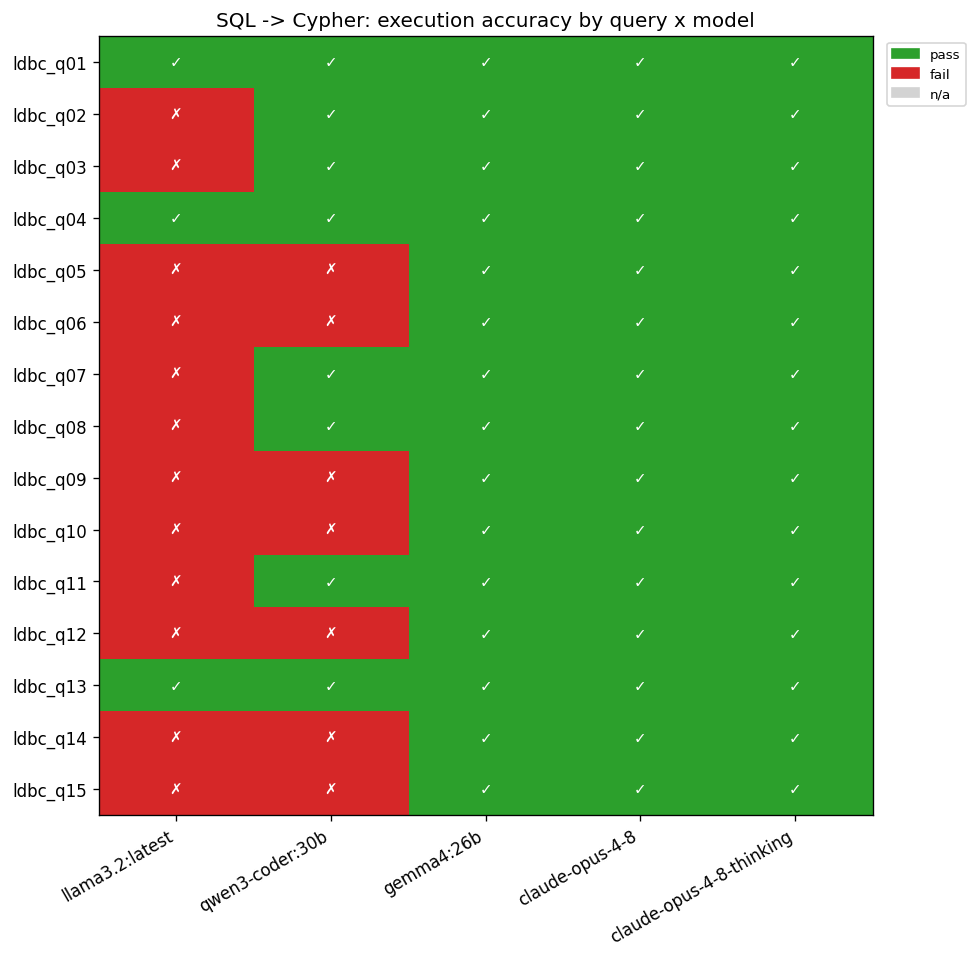

In [13]:
if sub is not None and len(sub):
    p = FIGURES_DIR / f"{prefix}_query_model_exec.png"
    plots.query_model_heatmap(sub, "execution_accuracy", p, discrete=True, title=f"{label}: execution accuracy by query x model", cbar_label="exec acc")
    plots.show(p)
    plt.close("all")
else:
    print(f"{label}: not executed this pass.")

#### Execution accuracy and result F1 per model

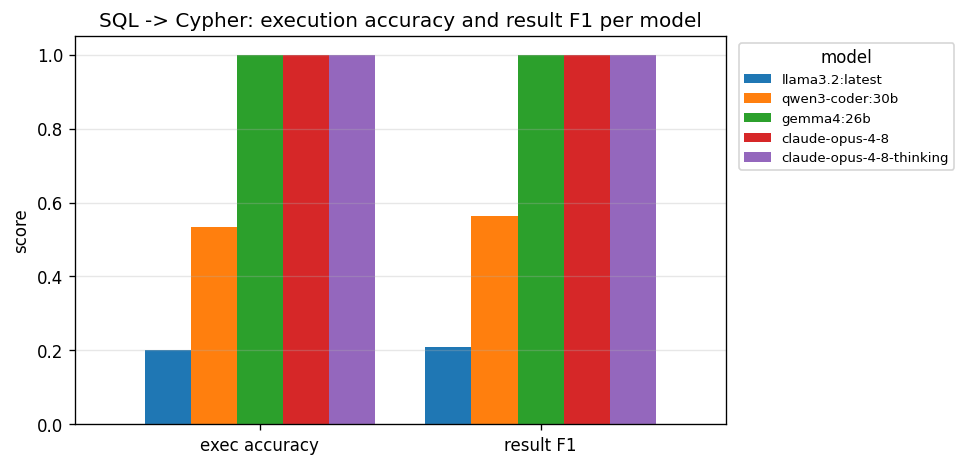

In [14]:
if sub is not None and len(sub):
    p = FIGURES_DIR / f"{prefix}_execution_bars.png"
    plots.per_model_bars(sub, ["execution_accuracy", "result_f1"], p, title=f"{label}: execution accuracy and result F1 per model", ylabel="score", labels={"execution_accuracy": "exec accuracy", "result_f1": "result F1"})
    plots.show(p)
    plt.close("all")
else:
    print(f"{label}: not executed this pass.")

## SQL to AQL

In [17]:
aql_frames = []  # per-model execution rows for this target

### llama3.2:latest

In [18]:
execute_model('aql', 'llama3.2:latest', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  2/15] ldbc_q02 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  3/15] ldbc_q03 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  4/15] ldbc_q04 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  5/15] ldbc_q05 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 400][ERR 1512] use of unknown va)
[  6/15] ldbc_q06 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  7/15] ldbc_q07 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  8/15] ldbc_q08 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[  9/15] ldbc_q09 (aql) skip (translation invalid)
[ 10/15] ldbc_q10 (aql) EXEC ERROR (AQLQueryExecuteError: [HTTP 404][ERR 1203] collection or vie)
[ 11/15] ldbc_q11 (aql) EXEC ERROR (A

,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.015554,1,0
1,ldbc_q02,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.004156,12932,0
2,ldbc_q03,easy,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.002968,4,0
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003810,10,0
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 400][ERR 1512] use...,0.003606,20,0
5,ldbc_q06,medium,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003700,5,0
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003879,58,0
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.003467,2805,0
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
9,ldbc_q10,hard,0.0,0.0,0.0,0.0,1.0,AQLQueryExecuteError: [HTTP 404][ERR 1203] col...,0.052171,90492,0


### qwen3-coder:30b

In [19]:
execute_model('aql', 'qwen3-coder:30b', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (aql) ne EX=0 F1=0.00 ref=10 trans=10
[  5/15] ldbc_q05 (aql) ne EX=0 F1=0.00 ref=20 trans=0
[  6/15] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (aql) ne EX=0 F1=0.00 ref=58 trans=58
[  8/15] ldbc_q08 (aql) ne EX=0 F1=0.00 ref=2805 trans=21084
[  9/15] ldbc_q09 (aql) ne EX=0 F1=0.00 ref=20 trans=0
[ 10/15] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/15] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (aql) ne EX=0 F1=0.00 ref=111 trans=0
[ 15/15] ldbc_q15 (aql) ne EX=0 F1=0.00 ref=3 trans=2


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.022959,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,0.759179,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.008612,4,4
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,None,35.371108,10,10
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,None,10.211334,20,0
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.013498,5,5
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,None,0.324120,58,58
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,None,55.596930,2805,21084
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,None,17.444494,20,0
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,17.261327,90492,90492


### gemma4:26b

In [20]:
execute_model('aql', 'gemma4:26b', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (aql) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (aql) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (aql) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/15] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (aql) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (aql) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.024073,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,0.129444,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.007563,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,0.962403,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,47.698776,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.006416,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.011460,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,28.666390,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,122.338881,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,1.487898,90492,90492


### claude-opus-4-8

In [21]:
execute_model('aql', 'claude-opus-4-8', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (aql) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (aql) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (aql) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/15] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (aql) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (aql) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.007408,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,0.133319,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.005769,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,15.476401,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,118.041009,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.006029,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.010719,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,25.430907,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,53.819913,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,17.011979,90492,90492


### claude-opus-4-8-thinking

In [22]:
execute_model('aql', 'claude-opus-4-8-thinking', aql_frames)

aql: 15 executable record(s).
[  1/15] ldbc_q01 (aql) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (aql) ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/15] ldbc_q03 (aql) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (aql) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (aql) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (aql) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (aql) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (aql) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (aql) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (aql) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (aql) ne EX=0 F1=0.00 ref=917 trans=1
[ 13/15] ldbc_q13 (aql) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (aql) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (aql) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.0,1.0,1.0,0.0,None,0.006157,1,1
1,ldbc_q02,easy,1.0,1.0,1.0,1.0,0.0,None,0.109704,12932,12932
2,ldbc_q03,easy,1.0,1.0,1.0,1.0,0.0,None,0.006541,4,4
3,ldbc_q04,hard,1.0,1.0,1.0,1.0,0.0,None,14.961423,10,10
4,ldbc_q05,hard,1.0,1.0,1.0,1.0,0.0,None,43.246141,20,20
5,ldbc_q06,medium,1.0,1.0,1.0,1.0,0.0,None,0.006319,5,5
6,ldbc_q07,medium,1.0,1.0,1.0,1.0,0.0,None,0.011207,58,58
7,ldbc_q08,hard,1.0,1.0,1.0,1.0,0.0,None,27.995240,2805,2805
8,ldbc_q09,medium,1.0,1.0,1.0,1.0,0.0,None,0.366302,20,20
9,ldbc_q10,hard,1.0,1.0,1.0,1.0,0.0,None,16.259504,90492,90492


### Aggregation by model

In [23]:
aql_exec_df = pd.concat(aql_frames, ignore_index=True) if aql_frames else None
summary_by_model(aql_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
llama3.2:latest,0.000000,0.000000,0.000000,0.000000,1.000000
qwen3-coder:30b,0.466667,0.466667,0.466667,0.466667,0.533333
gemma4:26b,0.933333,0.933333,0.933333,0.933333,0.066667
claude-opus-4-8,0.933333,0.933333,0.933333,0.933333,0.066667
claude-opus-4-8-thinking,0.933333,0.933333,0.933333,0.933333,0.066667


### Figures

In [24]:
sub = aql_exec_df
label = 'SQL -> AQL'
prefix = 'aql'

#### Execution accuracy by query x model

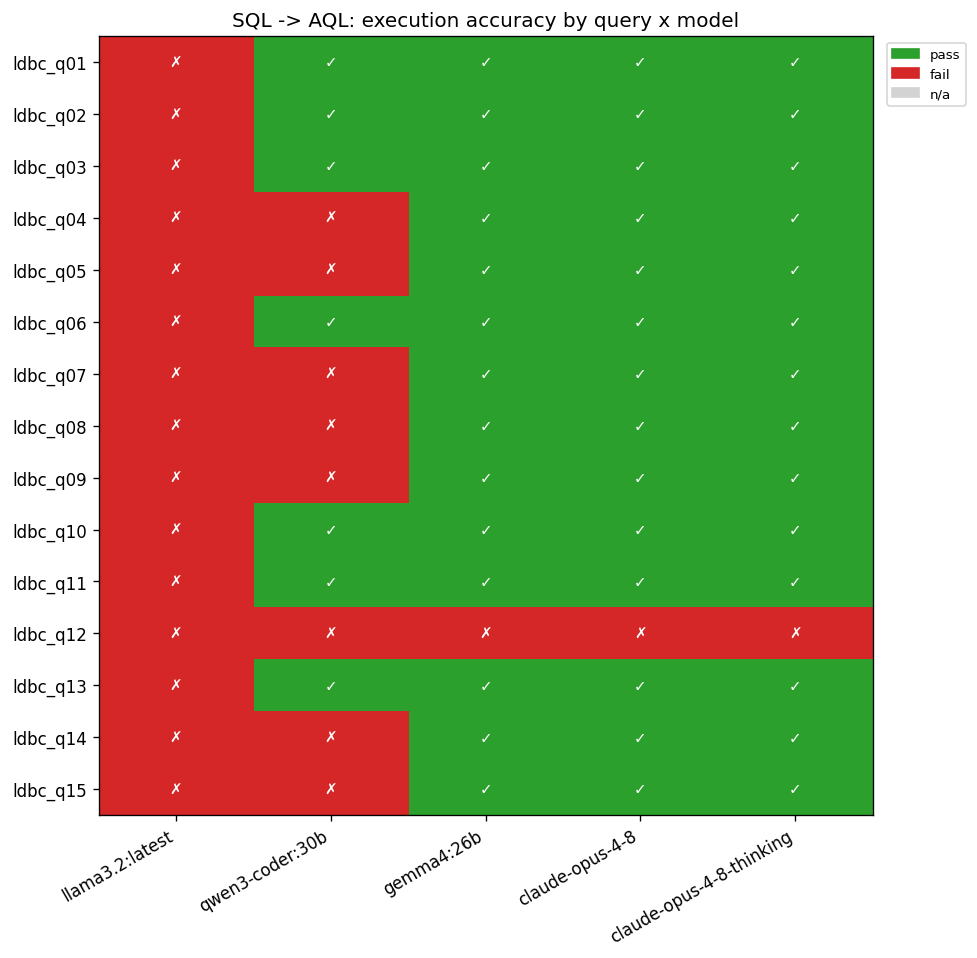

In [25]:
if sub is not None and len(sub):
    p = FIGURES_DIR / f"{prefix}_query_model_exec.png"
    plots.query_model_heatmap(sub, "execution_accuracy", p, discrete=True, title=f"{label}: execution accuracy by query x model", cbar_label="exec acc")
    plots.show(p)
    plt.close("all")
else:
    print(f"{label}: not executed this pass.")

#### Execution accuracy and result F1 per model

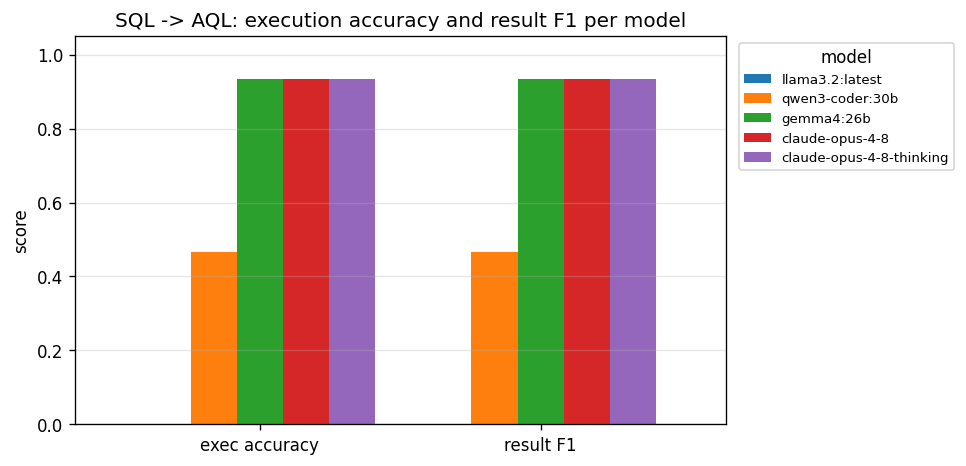

In [26]:
if sub is not None and len(sub):
    p = FIGURES_DIR / f"{prefix}_execution_bars.png"
    plots.per_model_bars(sub, ["execution_accuracy", "result_f1"], p, title=f"{label}: execution accuracy and result F1 per model", ylabel="score", labels={"execution_accuracy": "exec accuracy", "result_f1": "result F1"})
    plots.show(p)
    plt.close("all")
else:
    print(f"{label}: not executed this pass.")

## SQL to Gremlin

In [27]:
gremlin_frames = []  # per-model execution rows for this target

### llama3.2:latest

In [28]:
execute_model('gremlin', 'llama3.2:latest', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ne EX=0 F1=0.00 ref=1 trans=0
[  2/15] ldbc_q02 (gremlin) skip (translation invalid)
[  3/15] ldbc_q03 (gremlin) ne EX=0 F1=0.00 ref=4 trans=0
[  4/15] ldbc_q04 (gremlin) skip (translation invalid)
[  5/15] ldbc_q05 (gremlin) skip (translation invalid)
[  6/15] ldbc_q06 (gremlin) skip (translation invalid)
[  7/15] ldbc_q07 (gremlin) skip (translation invalid)
[  8/15] ldbc_q08 (gremlin) EXEC ERROR (GremlinServerError: 598: Evaluation exceeded the configured )
[  9/15] ldbc_q09 (gremlin) skip (translation invalid)
[ 10/15] ldbc_q10 (gremlin) skip (translation invalid)
[ 11/15] ldbc_q11 (gremlin) skip (translation invalid)
[ 12/15] ldbc_q12 (gremlin) skip (translation invalid)
[ 13/15] ldbc_q13 (gremlin) skip (translation invalid)
[ 14/15] ldbc_q14 (gremlin) skip (translation invalid)
[ 15/15] ldbc_q15 (gremlin) skip (translation invalid)


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,0.0,0.0,0.0,0.0,1.0,NaN,0.955481,1,0
1,ldbc_q02,easy,0.0,0.0,0.0,0.0,1.0,NaN,NaN,12932,0
2,ldbc_q03,easy,0.0,0.0,0.0,0.0,1.0,NaN,21.745248,4,0
3,ldbc_q04,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,10,0
4,ldbc_q05,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
5,ldbc_q06,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,5,0
6,ldbc_q07,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,58,0
7,ldbc_q08,hard,0.0,0.0,0.0,0.0,1.0,GremlinServerError: 598: Evaluation exceeded t...,181.435022,2805,0
8,ldbc_q09,medium,0.0,0.0,0.0,0.0,1.0,NaN,NaN,20,0
9,ldbc_q10,hard,0.0,0.0,0.0,0.0,1.0,NaN,NaN,90492,0


### qwen3-coder:30b

In [29]:
execute_model('gremlin', 'qwen3-coder:30b', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/15] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (gremlin) EXEC ERROR (GremlinServerError: 597: The by("member_count") modulator ca)
[  5/15] ldbc_q05 (gremlin) ne EX=0 F1=0.00 ref=20 trans=0
[  6/15] ldbc_q06 (gremlin) ne EX=0 F1=0.00 ref=5 trans=5
[  7/15] ldbc_q07 (gremlin) ne EX=0 F1=0.00 ref=58 trans=0
[  8/15] ldbc_q08 (gremlin) skip (translation invalid)
[  9/15] ldbc_q09 (gremlin) ne EX=0 F1=0.00 ref=20 trans=0
[ 10/15] ldbc_q10 (gremlin) EXEC ERROR (GremlinServerError: 597: The by("member_count") modulator ca)
[ 11/15] ldbc_q11 (gremlin) skip (translation invalid)
[ 12/15] ldbc_q12 (gremlin) skip (translation invalid)
[ 13/15] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (gremlin) ne EX=0 F1=0.00 ref=111 trans=1
[ 15/15] ldbc_q15 (gremlin) skip (translation invalid)


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,8.070344,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,NaN,4.232256,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,0.727875,4,4
3,ldbc_q04,hard,0.0,0.000000,0.000000,0.000000,1.000000,"GremlinServerError: 597: The by(""member_count""...",14.857069,10,0
4,ldbc_q05,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.295788,20,0
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.110546,5,5
6,ldbc_q07,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.241471,58,0
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,NaN,2805,0
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,1.322154,20,0
9,ldbc_q10,hard,0.0,0.000000,0.000000,0.000000,1.000000,"GremlinServerError: 597: The by(""member_count""...",1.967452,90492,0


### gemma4:26b

In [30]:
execute_model('gremlin', 'gemma4:26b', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/15] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (gremlin) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (gremlin) ne EX=0 F1=0.05 ref=20 trans=20
[  6/15] ldbc_q06 (gremlin) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (gremlin) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (gremlin) ne EX=0 F1=0.15 ref=2805 trans=35270
[  9/15] ldbc_q09 (gremlin) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (gremlin) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (gremlin) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (gremlin) ne EX=0 F1=1.00 ref=917 trans=916
[ 13/15] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (gremlin) ok EX=1 F1=1.00 ref=111 trans=111
[ 15/15] ldbc_q15 (gremlin) ne EX=0 F1=0.00 ref=3 trans=2


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,None,0.846700,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,None,5.364676,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,None,1.330891,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,2.973765,10,10
4,ldbc_q05,hard,0.0,0.050000,0.050000,0.050000,0.974359,None,9.276376,20,20
5,ldbc_q06,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,3.682047,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,8.060472,58,58
7,ldbc_q08,hard,0.0,0.079529,1.000000,0.147341,0.920471,None,14.083627,2805,35270
8,ldbc_q09,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,19.322020,20,20
9,ldbc_q10,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,4.913455,90492,90492


### claude-opus-4-8

In [31]:
execute_model('gremlin', 'claude-opus-4-8', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/15] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (gremlin) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (gremlin) ne EX=0 F1=0.05 ref=20 trans=20
[  6/15] ldbc_q06 (gremlin) ne EX=0 F1=0.00 ref=5 trans=5
[  7/15] ldbc_q07 (gremlin) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (gremlin) ne EX=0 F1=0.00 ref=2805 trans=2423
[  9/15] ldbc_q09 (gremlin) ne EX=0 F1=0.00 ref=20 trans=20
[ 10/15] ldbc_q10 (gremlin) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (gremlin) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (gremlin) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (gremlin) ne EX=0 F1=0.00 ref=111 trans=1
[ 15/15] ldbc_q15 (gremlin) EXEC ERROR (KeyError: <DataType.tree: 43>)


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,2.677855,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,NaN,3.637099,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,NaN,0.812911,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.000000,NaN,2.148841,10,10
4,ldbc_q05,hard,0.0,0.050000,0.050000,0.050000,0.974359,NaN,1.748228,20,20
5,ldbc_q06,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,0.729046,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.000000,NaN,1.824964,58,58
7,ldbc_q08,hard,0.0,0.000000,0.000000,0.000000,1.000000,NaN,6.999765,2805,2423
8,ldbc_q09,medium,0.0,0.000000,0.000000,0.000000,1.000000,NaN,8.153870,20,20
9,ldbc_q10,hard,1.0,1.000000,1.000000,1.000000,0.000000,NaN,4.986082,90492,90492


### claude-opus-4-8-thinking

In [32]:
execute_model('gremlin', 'claude-opus-4-8-thinking', gremlin_frames)

gremlin: 15 executable record(s).
[  1/15] ldbc_q01 (gremlin) ok EX=1 F1=1.00 ref=1 trans=1
[  2/15] ldbc_q02 (gremlin) ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/15] ldbc_q03 (gremlin) ok EX=1 F1=1.00 ref=4 trans=4
[  4/15] ldbc_q04 (gremlin) ok EX=1 F1=1.00 ref=10 trans=10
[  5/15] ldbc_q05 (gremlin) ok EX=1 F1=1.00 ref=20 trans=20
[  6/15] ldbc_q06 (gremlin) ok EX=1 F1=1.00 ref=5 trans=5
[  7/15] ldbc_q07 (gremlin) ok EX=1 F1=1.00 ref=58 trans=58
[  8/15] ldbc_q08 (gremlin) ok EX=1 F1=1.00 ref=2805 trans=2805
[  9/15] ldbc_q09 (gremlin) ok EX=1 F1=1.00 ref=20 trans=20
[ 10/15] ldbc_q10 (gremlin) ok EX=1 F1=1.00 ref=90492 trans=90492
[ 11/15] ldbc_q11 (gremlin) ok EX=1 F1=1.00 ref=5407 trans=5407
[ 12/15] ldbc_q12 (gremlin) ok EX=1 F1=1.00 ref=917 trans=917
[ 13/15] ldbc_q13 (gremlin) ok EX=1 F1=1.00 ref=1642 trans=1642
[ 14/15] ldbc_q14 (gremlin) ne EX=0 F1=0.00 ref=111 trans=1
[ 15/15] ldbc_q15 (gremlin) ok EX=1 F1=1.00 ref=3 trans=3


,query_id,difficulty,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,execution_error,translated_runtime_s,reference_rows,translated_rows
0,ldbc_q01,easy,1.0,1.000000,1.000000,1.000000,0.000000,None,0.985623,1,1
1,ldbc_q02,easy,0.0,0.315032,0.315032,0.315032,0.813034,None,1.956355,12932,12932
2,ldbc_q03,easy,1.0,1.000000,1.000000,1.000000,0.000000,None,0.749162,4,4
3,ldbc_q04,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,1.559679,10,10
4,ldbc_q05,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,4.683754,20,20
5,ldbc_q06,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,1.254669,5,5
6,ldbc_q07,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,2.131187,58,58
7,ldbc_q08,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,5.954982,2805,2805
8,ldbc_q09,medium,1.0,1.000000,1.000000,1.000000,0.000000,None,8.909041,20,20
9,ldbc_q10,hard,1.0,1.000000,1.000000,1.000000,0.000000,None,4.853475,90492,90492


### Aggregation by model

In [33]:
gremlin_exec_df = pd.concat(gremlin_frames, ignore_index=True) if gremlin_frames else None
summary_by_model(gremlin_exec_df)

,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist
model,,,,,
llama3.2:latest,0.000000,0.000000,0.000000,0.000000,1.000000
qwen3-coder:30b,0.200000,0.221002,0.221002,0.221002,0.787536
gemma4:26b,0.666667,0.762971,0.824263,0.767455,0.247264
claude-opus-4-8,0.533333,0.557669,0.557669,0.557669,0.452493
claude-opus-4-8-thinking,0.866667,0.887669,0.887669,0.887669,0.120869


### Figures

In [34]:
sub = gremlin_exec_df
label = 'SQL -> Gremlin'
prefix = 'gremlin'

#### Execution accuracy by query x model

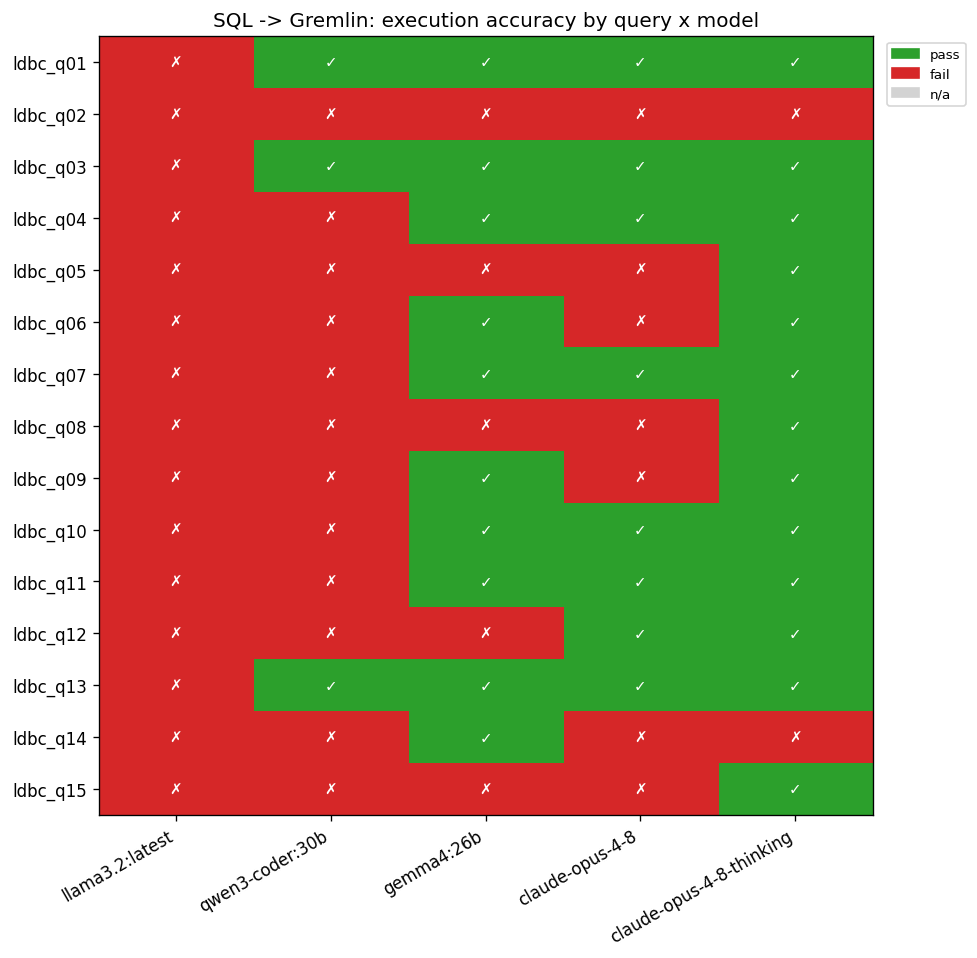

In [35]:
if sub is not None and len(sub):
    p = FIGURES_DIR / f"{prefix}_query_model_exec.png"
    plots.query_model_heatmap(sub, "execution_accuracy", p, discrete=True, title=f"{label}: execution accuracy by query x model", cbar_label="exec acc")
    plots.show(p)
    plt.close("all")
else:
    print(f"{label}: not executed this pass.")

#### Execution accuracy and result F1 per model

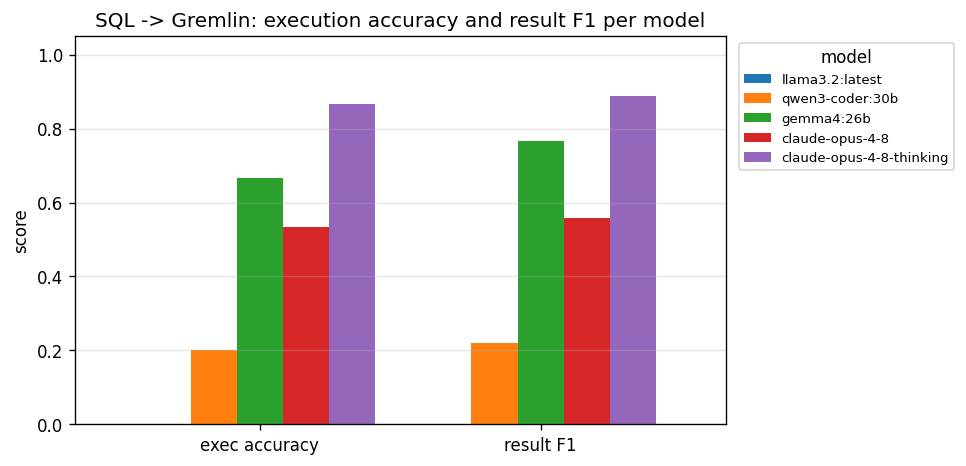

In [36]:
if sub is not None and len(sub):
    p = FIGURES_DIR / f"{prefix}_execution_bars.png"
    plots.per_model_bars(sub, ["execution_accuracy", "result_f1"], p, title=f"{label}: execution accuracy and result F1 per model", ylabel="score", labels={"execution_accuracy": "exec accuracy", "result_f1": "result F1"})
    plots.show(p)
    plt.close("all")
else:
    print(f"{label}: not executed this pass.")

## Run-level summary and save

Merge this pass's targets into the CSV, preserving the rows of any target not executed now (backends cannot all run at once).

In [37]:
new_frames = {t: f for t, f in (("cypher", cypher_exec_df), ("aql", aql_exec_df),
                                ("gremlin", gremlin_exec_df)) if f is not None}
if OUT_CSV.exists():
    exec_all = pd.read_csv(OUT_CSV)
    exec_all = exec_all[~exec_all["target"].isin(new_frames)]
else:
    exec_all = pd.DataFrame()
to_concat = ([exec_all] if len(exec_all) else []) + [f for f in new_frames.values() if len(f)]
exec_all = pd.concat(to_concat, ignore_index=True) if to_concat else pd.DataFrame()
if len(exec_all):
    e = frames.order_frame_models(exec_all)
    print("By target x model:")
    display(e.groupby(["target", "model"], observed=True)[EXEC_METRIC_COLS].mean())
    print("By target x SQL feature:")
    display(by_feature(exec_all, EXEC_METRIC_COLS))
exec_all.to_csv(OUT_CSV, index=False)
print(f"Wrote {len(exec_all)} rows to {OUT_CSV} (executed this pass: {', '.join(new_frames) or 'none'}).")
ex.close_clients()

By target x model:


execution_accuracy  result_precision  \
target  model                                                            
aql     llama3.2:latest                     0.000000          0.000000   
        qwen3-coder:30b                     0.466667          0.466667   
        gemma4:26b                          0.933333          0.933333   
        claude-opus-4-8                     0.933333          0.933333   
        claude-opus-4-8-thinking            0.933333          0.933333   
cypher  llama3.2:latest                     0.200000          0.208120   
        qwen3-coder:30b                     0.533333          0.563676   
        gemma4:26b                          1.000000          1.000000   
        claude-opus-4-8                     1.000000          1.000000   
        claude-opus-4-8-thinking            1.000000          1.000000   
gremlin llama3.2:latest                     0.000000          0.000000   
        qwen3-coder:30b                     0.200000          0.221002   
        gemma4:26b                          0.666667          0.762971   
        claude-opus-4-8                     0.533333          0.557669   
        claude-opus-4-8-thinking            0.866667          0.887669   

                                  result_recall  result_f1  \
target  model                                                
aql     llama3.2:latest                0.000000   0.000000   
        qwen3-coder:30b                0.466667   0.466667   
        gemma4:26b                     0.933333   0.933333   
        claude-opus-4-8                0.933333   0.933333   
        claude-opus-4-8-thinking       0.933333   0.933333   
cypher  llama3.2:latest                0.208120   0.208120   
        qwen3-coder:30b                0.563676   0.563676   
        gemma4:26b                     1.000000   1.000000   
        claude-opus-4-8                1.000000   1.000000   
        claude-opus-4-8-thinking       1.000000   1.000000   
gremlin llama3.2:latest                0.000000   0.000000   
        qwen3-coder:30b                0.221002   0.221002   
        gemma4:26b                     0.824263   0.767455   
        claude-opus-4-8                0.557669   0.557669   
        claude-opus-4-8-thinking       0.887669   0.887669   

                                  result_jaccard_dist  
target  model                                          
aql     llama3.2:latest                      1.000000  
        qwen3-coder:30b                      0.533333  
        gemma4:26b                           0.066667  
        claude-opus-4-8                      0.066667  
        claude-opus-4-8-thinking             0.066667  
cypher  llama3.2:latest                      0.795677  
        qwen3-coder:30b                      0.449010  
        gemma4:26b                           0.000000  
        claude-opus-4-8                      0.000000  
        claude-opus-4-8-thinking             0.000000  
gremlin llama3.2:latest                      1.000000  
        qwen3-coder:30b                      0.787536  
        gemma4:26b                           0.247264  
        claude-opus-4-8                      0.452493  
        claude-opus-4-8-thinking             0.120869

By target x SQL feature:


execution_accuracy  result_precision  result_recall  \
target  feature                                                            
aql     aggregation            0.680000          0.680000       0.680000   
        cte                    0.600000          0.600000       0.600000   
        distinct               0.300000          0.300000       0.300000   
        join                   0.600000          0.600000       0.600000   
        order_limit            0.666667          0.666667       0.666667   
        subquery               0.700000          0.700000       0.700000   
        temporal               0.700000          0.700000       0.700000   
        union                  0.400000          0.400000       0.400000   
cypher  aggregation            0.720000          0.729744       0.729744   
        cte                    0.600000          0.666667       0.666667   
        distinct               0.700000          0.700000       0.700000   
        join                   0.690909          0.701399       0.701399   
        order_limit            0.700000          0.719231       0.719231   
        subquery               0.800000          0.800000       0.800000   
        temporal               0.800000          0.800000       0.800000   
        union                  0.600000          0.622222       0.622222   
gremlin aggregation            0.440000          0.444000       0.444000   
        cte                    0.200000          0.200000       0.200000   
        distinct               0.300000          0.407953       0.499891   
        join                   0.400000          0.421446       0.438162   
        order_limit            0.433333          0.436667       0.436667   
        subquery               0.500000          0.510000       0.510000   
        temporal               0.300000          0.426013       0.426013   
        union                  0.266667          0.340000       0.339927   

                     result_f1  result_jaccard_dist  
target  feature                                      
aql     aggregation   0.680000             0.320000  
        cte           0.600000             0.400000  
        distinct      0.300000             0.700000  
        join          0.600000             0.400000  
        order_limit   0.666667             0.333333  
        subquery      0.700000             0.300000  
        temporal      0.700000             0.300000  
        union         0.400000             0.600000  
cypher  aggregation   0.729744             0.274812  
        cte           0.666667             0.360000  
        distinct      0.700000             0.300000  
        join          0.701399             0.303096  
        order_limit   0.719231             0.289010  
        subquery      0.800000             0.200000  
        temporal      0.800000             0.200000  
        union         0.622222             0.386667  
gremlin aggregation   0.444000             0.557949  
        cte           0.200000             0.800000  
        distinct      0.414680             0.592156  
        join          0.422669             0.579460  
        order_limit   0.436667             0.564957  
        subquery      0.510000             0.494872  
        temporal      0.426013             0.625213  
        union         0.339964             0.663321

Wrote 225 rows to /Users/ivona.obonova/school/sql2graph/sql2graph/eval/outputs/metrics/metrics_execution.csv (executed this pass: cypher, aql, gremlin).


## Summary

Execution is where the models, and the target languages, separate. On the declarative targets precision, recall, and F1 track EX closely (failures are all-or-nothing). Gremlin roughly halves the strongest configurations and crushes the weakest; how far extended thinking recovers that gap is the evaluation's headline, dissected in notebook 06 and the thesis.

Wrote `metrics_execution.csv`. Proceed to **`06_report.ipynb`**.